In [1]:
#installing required libraries
!pip install pyspark==3.5.1 -qq #distributed data processing
!pip install pandas -qq #small local operations
!pip install matplotlib -qq #plotting graphs
!pip install scikit-learn -qq #machine learning
!pip install pyarrow -qq #spark/panda interpretability

ERROR: Invalid requirement: '#distributed': Expected package name at the start of dependency specifier
    #distributed
    ^
ERROR: Invalid requirement: '#small': Expected package name at the start of dependency specifier
    #small
    ^
ERROR: Invalid requirement: '#plotting': Expected package name at the start of dependency specifier
    #plotting
    ^
ERROR: Invalid requirement: '#machine': Expected package name at the start of dependency specifier
    #machine
    ^
ERROR: Invalid requirement: '#spark/panda': Expected package name at the start of dependency specifier
    #spark/panda
    ^


In [2]:
#key imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#spark session and SQL functions
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType

#Spark ML tools for feature engineering and recomedation
from pyspark.ml.feature import StringIndexer, Tokenizer, HashingTF, IDF
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.linalg import Vectors


In [3]:
#creating spark session

#environemnt variables that make spark use the same python interpreter as when the notebook is running.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

#build local spark session
spark = (
    SparkSession.builder
    .appName("SCC454-Amazon")
    .master("local[2]")#use 2 CPU threads locallu
    .config("spark.ui.port", "4050")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.python.worker.reuse", "true")
    .config("spark.driver.memory","4g")
    .config("spark.executor.memory","4g")

    .getOrCreate()
)

#reduce spark log noise
spark.sparkContext.setLogLevel("ERROR")
sc = spark.sparkContext



In [4]:
#Load data

# File paths
reviews_path = r"C:\Users\Egome\PycharmProjects\SCC454_Amazon\data\cleaned_reviews.jsonl"
metadata_path = r"C:\Users\Egome\PycharmProjects\SCC454_Amazon\data\cleaned_metadata.jsonl"

#read cleaned review data into spark df
reviews = spark.read.json(reviews_path)

#read cleaned product meta data into spark df
products = spark.read.json(metadata_path)

In [5]:
#check main recommender columns exists
reviews.select("user_id", "parent_asin", "rating").show(5)

# print schema for both data sets for visulisation
reviews.printSchema()
products.printSchema()

+--------------------+-----------+------+
|             user_id|parent_asin|rating|
+--------------------+-----------+------+
|AGKHLEW2SOWHNMFQI...| B00YQ6X8EO|   5.0|
|AGKHLEW2SOWHNMFQI...| B081TJ8YS3|   4.0|
|AE74DYR3QUGVPZJ3P...| B097R46CSY|   5.0|
|AFQLNQNQYFWQZPJQZ...| B09JS339BZ|   1.0|
|AFQLNQNQYFWQZPJQZ...| B08BZ63GMJ|   5.0|
+--------------------+-----------+------+
only showing top 5 rows

root
 |-- helpful_vote: long (nullable = true)
 |-- month: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- timestamp_convert: string (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- year: long (nullable = true)

root
 |-- Age Range (Description): string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Hair Type: string (nullable = true)
 |-- Item F

In [6]:
#build ratings dataframe

#fields required for recommendation
#user_id - users rating
#parent_asin - product rated
#rating - score

#cast the rating double type and drop the missing values
ratings = reviews.select(
    "user_id",
    "parent_asin",
    F.col("rating").cast("double").alias("rating")
).dropna(subset=["user_id", "parent_asin", "rating"]) \
 .withColumn("rating_id", F.monotonically_increasing_id())

# print schema to check rating table
ratings.printSchema()
ratings.show(5, truncate=False)

# ONE shared split for all recommenders:
# train_full = used for model building/tuning pool
# test = final untouched evaluation only
ratings_train_full, ratings_test = ratings.randomSplit([0.8, 0.2], seed=42)

# split the training portion again into inner-train + validation
ratings_train, ratings_valid = ratings_train_full.randomSplit([0.8, 0.2], seed=42)

ratings_train_full = ratings_train_full.cache()
ratings_train = ratings_train.cache()
ratings_valid = ratings_valid.cache()
ratings_test = ratings_test.cache()

print(f"ratings_train_full: {ratings_train_full.count():,}")
print(f"ratings_train:      {ratings_train.count():,}")
print(f"ratings_valid:      {ratings_valid.count():,}")
print(f"ratings_test:       {ratings_test.count():,}")

root
 |-- user_id: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- rating_id: long (nullable = false)

+----------------------------+-----------+------+---------+
|user_id                     |parent_asin|rating|rating_id|
+----------------------------+-----------+------+---------+
|AGKHLEW2SOWHNMFQIJGBECAF7INQ|B00YQ6X8EO |5.0   |0        |
|AGKHLEW2SOWHNMFQIJGBECAF7INQ|B081TJ8YS3 |4.0   |1        |
|AE74DYR3QUGVPZJ3P7RFWBGIX7XQ|B097R46CSY |5.0   |2        |
|AFQLNQNQYFWQZPJQZS6V3NZU4QBQ|B09JS339BZ |1.0   |3        |
|AFQLNQNQYFWQZPJQZS6V3NZU4QBQ|B08BZ63GMJ |5.0   |4        |
+----------------------------+-----------+------+---------+
only showing top 5 rows

ratings_train_full: 561,100
ratings_train:      448,722
ratings_valid:      112,378
ratings_test:       140,428


In [7]:
# exploratory data analysis
#checking data sparsity
#because reccomender systems behave differently
#depending on the sparsity
# statistics
#total number of ratings
num_ratings = ratings.count()
#number of unique users
num_users = ratings.select("user_id").distinct().count()
#number of unique products
num_products = ratings.select("parent_asin").distinct().count()
#total number of products in metadata
total_products = products.select("parent_asin").distinct().count()

#sparsity of matrix
sparsity = 1 - (num_ratings / (num_users * total_products))

#printing stats
print(num_ratings, num_users, num_products, sparsity)

701528 631986 112565 0.9999901408895314


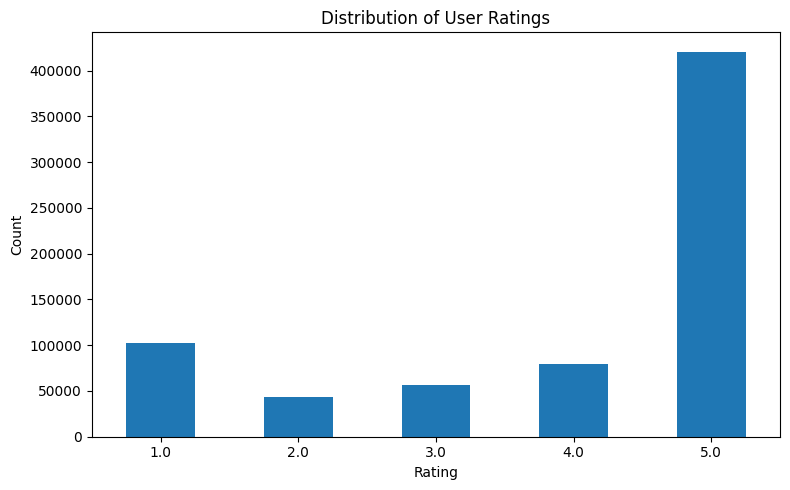

In [8]:
#ratings distribution
ratings_pd = ratings.select("rating").toPandas()

plt.figure(figsize=(8,5))
ratings_pd["rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of User Ratings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Distribution_of_User_Ratings.png", dpi=300, bbox_inches="tight")
plt.show()

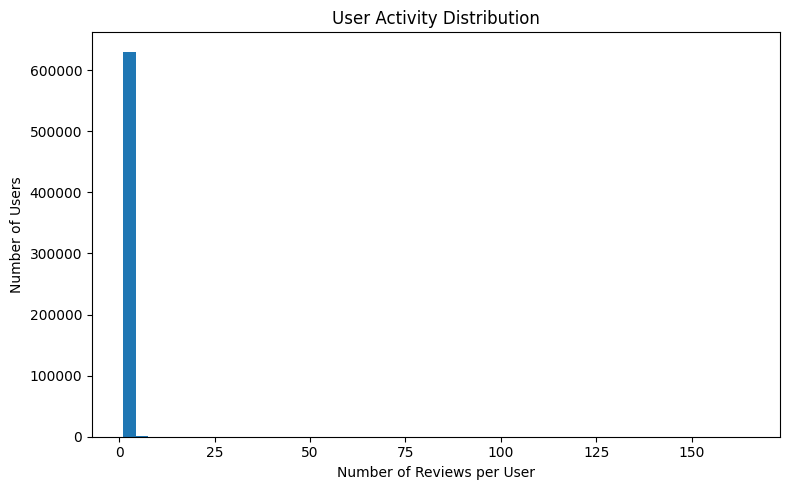

In [9]:
#user activity
user_activity = ratings.groupBy("user_id").count().toPandas()

plt.figure(figsize=(8,5))
plt.hist(user_activity["count"], bins=50)
plt.xlabel("Number of Reviews per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")
plt.tight_layout()
plt.savefig("User_Activity_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

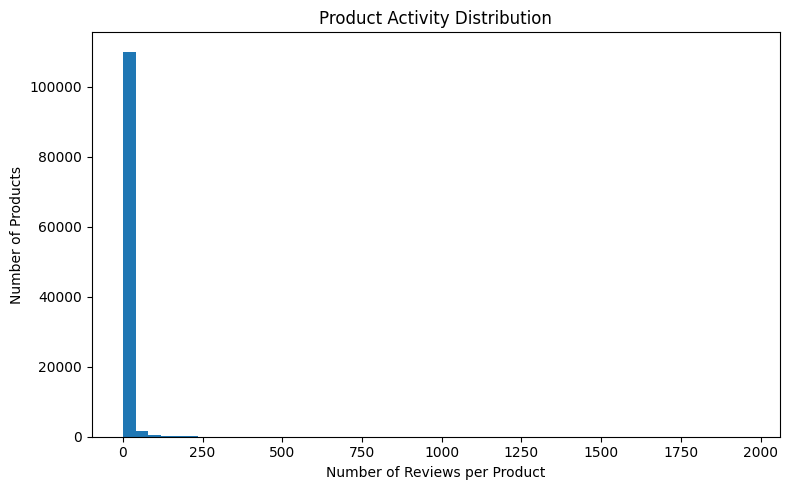

In [10]:
#product activity
item_activity = ratings.groupBy("parent_asin").count().toPandas()

plt.figure(figsize=(8,5))
plt.hist(item_activity["count"], bins=50)
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.title("Product Activity Distribution")
plt.tight_layout()
plt.savefig("Product_Activity_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Popularity baseline

#simple baseline recommender

#aggregate ratings by product
# Uses average rating and review count to rank products
#joins product meta data
#adds product title from roducts dataframe
#makes recommendations readable instead of ASIN ID's
popular_products = ratings_train.groupBy("parent_asin").agg(
    F.avg("rating").alias("avg_rating"),
    F.count("*").alias("review_count")
).join(
    products.select("parent_asin", "title"),
    on="parent_asin",
    how="left"
)

#create popularity score
#score combines rating quality and popularity
#log1p the review_count reduces the impact of extremely large review counts
popular_products = popular_products.withColumn(
    "popularity_score",
    F.col("avg_rating") * F.log1p(F.col("review_count"))
)

#sort products by highest popularity score and display the top 10 most popular products
popular_products.orderBy(F.desc("popularity_score")).show(10, truncate=False)

+-----------+------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|parent_asin|avg_rating        |review_count|title                                                                                                                                                     |popularity_score  |
+-----------+------------------+------------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|B085BB7B1M |4.608486789431545 |1249        |salux nylon japanese beauty skin bath wash cloth towel 3 blue yellow pink                                                                                 |32.86265305619357 |
|B0C9CWKY9G |4.853856562922869 |739         |picoway 20 pack mouse ear solid black red bow headband                     

C:\Users\Egome\AppData\Local\Temp\ipykernel_24544\437054976.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


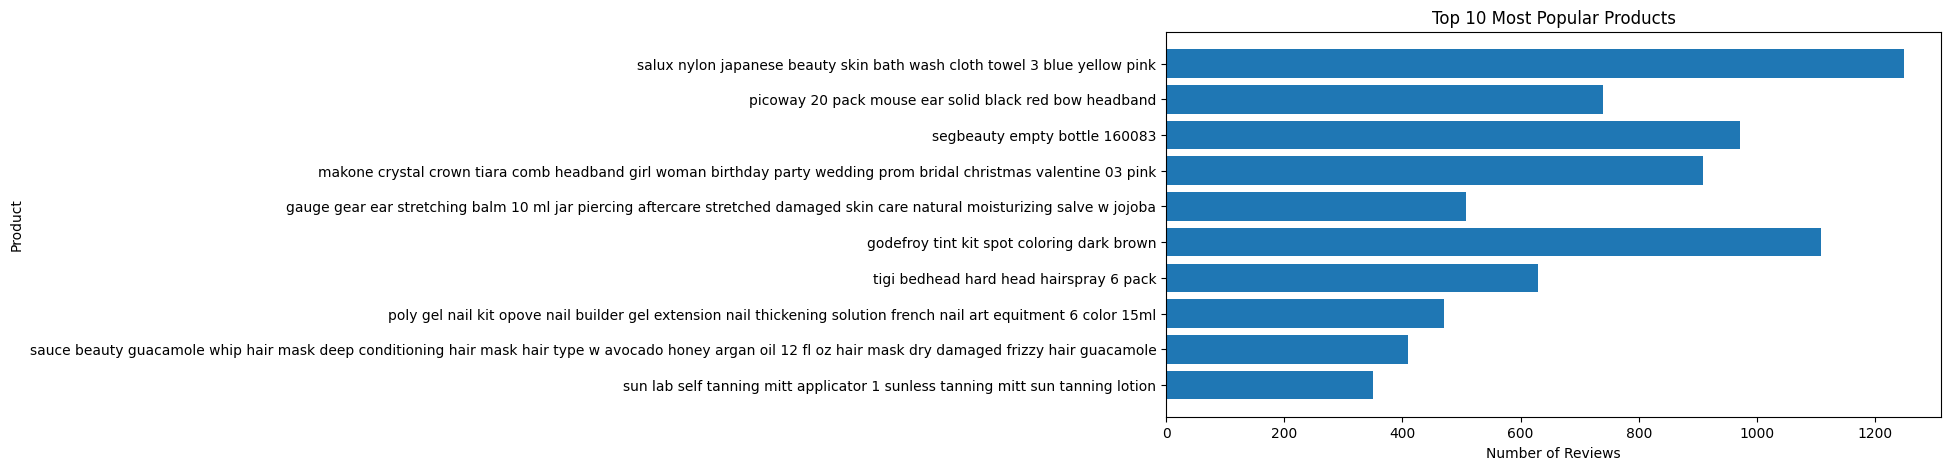

In [12]:
# graph - top 10 most popular products
top_popular_pd = popular_products.orderBy(F.desc("popularity_score")) \
    .select("title", "review_count", "popularity_score") \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(10,5))
plt.barh(top_popular_pd["title"], top_popular_pd["review_count"])
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.title("Top 10 Most Popular Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Top_10_Most_Popular_Products.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
def popularity_recommend(user_id, ratings_df, popularity_df, top_n=10):
    #recommends the most popular items that the user hasnt already rated
    #finds products the user has already seen/rated
    #removed those from the popularity table
    #return the top-n highest popularity score

    #products already rated by this user
    seen = ratings_df.filter(
        F.col("user_id") == user_id
    ).select("parent_asin").distinct()

    #keep only unseen products and sort by popularity
    recs = popularity_df.join(
        seen, "parent_asin", "left_anti"
    ).orderBy(
        F.desc("popularity_score")
    ).select(
        "parent_asin", "title", "popularity_score"
    ).limit(top_n)

    #prints popularity recommendations for user
    print(f"\nTop {top_n} Popularity Recommendations for User {user_id}:")
    recs.show(truncate=False)

    return recs

In [14]:
def random_recommend(user_id, ratings_df, products_df, top_n=10):
    seen = ratings_df.filter(
        F.col("user_id") == user_id
    ).select("parent_asin").distinct()

    recs = products_df.select("parent_asin", "title").join(
        seen, "parent_asin", "left_anti"
    ).orderBy(F.rand()).limit(top_n)

    print(f"\nTop {top_n} Random Recommendations for User {user_id}:")
    recs.show(truncate=False)
    return recs

In [15]:
def evaluate_random_precision_at_k(user_ids, train_df, test_df, products_df, k=10, relevance_threshold=4.0):
    total_precision = 0.0
    valid_users = 0

    relevant_items_df = test_df.filter(
        (F.col("user_id").isin(user_ids)) & (F.col("rating") >= relevance_threshold)
    ).select("user_id", "parent_asin").distinct()

    for user_id in user_ids:
        seen = train_df.filter(
            F.col("user_id") == user_id
        ).select("parent_asin").distinct()

        recs_df = products_df.select("parent_asin").join(
            seen, "parent_asin", "left_anti"
        ).orderBy(F.rand(42)).limit(k)

        recommended_asins = {row["parent_asin"] for row in recs_df.collect()}

        user_relevant = {
            row["parent_asin"]
            for row in relevant_items_df.filter(F.col("user_id") == user_id).collect()
        }

        if len(user_relevant) == 0:
            continue

        hits = len(recommended_asins.intersection(user_relevant))
        total_precision += hits / k
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nRandom Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [16]:
# Test popularity baseline on one sample user
sample_user = ratings_train.select("user_id").distinct().limit(1).collect()[0]["user_id"]
popularity_recommend(sample_user, ratings_train, popular_products, top_n=10)


Top 10 Popularity Recommendations for User AE222BBOVZIF42YOOPNBXL4UUMYA:
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|parent_asin|title                                                                                                                                                     |popularity_score  |
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|B085BB7B1M |salux nylon japanese beauty skin bath wash cloth towel 3 blue yellow pink                                                                                 |32.86265305619357 |
|B0C9CWKY9G |picoway 20 pack mouse ear solid black red bow headband                                                                                                    |32.067

DataFrame[parent_asin: string, title: string, popularity_score: double]

In [17]:
def cold_start_new_user_recommend(popularity_df, top_n=10):
    recs = popularity_df.orderBy(F.desc("popularity_score")) \
        .select("parent_asin", "title", "popularity_score") \
        .limit(top_n)

    print(f"\nCold-start recommendations for a new user (top {top_n}):")
    recs.show(truncate=False)
    return recs

content based filtering
recomending items similar to what user has previously liked
-build item profiles - feature vector using TF-IDF
-build user profiles - aggregate profiles of items user rated high
-predict- compute similarity - distance between user profile and candidate items - using cosine
-recommend items where the vectors are most similar to the user profile

In [18]:
# merge title and description into a single text field per product
product_content = products.withColumn(
    "content_text",
    F.concat_ws(
        " ",
        F.coalesce(F.col("title"), F.lit("")),
        F.coalesce(F.col("description"), F.lit(""))
    )
)

product_content.select("parent_asin", "title", "content_text").show(5, truncate=80)

# tokenise the text into list of words
tokenizer = Tokenizer(inputCol="content_text", outputCol="words")
product_words = tokenizer.transform(product_content)

# convert token lists into hash frequency vectors using hashing (HashingTF)
# numFeatures controls the dimensionality of hash space — larger = fewer collisions
hashingTF = HashingTF(inputCol="words", outputCol="raw_features", numFeatures=256)
product_tf = hashingTF.transform(product_words)

# apply IDF weighting so common words have less importance
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(product_tf)
product_tfidf = idf_model.transform(product_tf)

# cache the result
product_tfidf = product_tfidf.select(
    "parent_asin",
    "title",
    "content_text",
    "tfidf_features"
).cache()

#print to check vectors
product_tfidf.show(3, truncate=60)

+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|parent_asin|                                                                           title|                                                                    content_text|
+-----------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
| B01CUPMQZE|                                 howard lc008 leather conditioner 8 ounce 4 pack|                                howard lc008 leather conditioner 8 ounce 4 pack |
| B076WQZGPM|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit ...|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit ...|
| B000B658RI|                                       eye patch black adult tie band 6 per pack|                          

In [19]:
# Test: inspect some product titles
product_tfidf.select("title").show(20, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|title                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|howard lc008 leather conditioner 8 ounce 4 pack                                                                                                                                         |
|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit extract gingko biloba leaf extract 5 fl oz                                                                 |
|eye patch black adult tie band 6 per pack                       

compute item-item similarity between tf-idf vectors using cosine
equation - cos(x,i)=x⋅i/∥x∥⋅∥i∥

In [20]:
def cosine_similarity(v1, v2):
    #compute cosine similarity between two spark ML vectors

    #convert spark vecotrs to NumPy arrays
    a1 = v1.toArray()
    a2 = v2.toArray()

    #dot product measures the alignment
    dot = float(np.dot(a1, a2))
    norm1 = float(np.linalg.norm(a1))
    norm2 = float(np.linalg.norm(a2))

    #avoid division by zero for empty vectors
    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / (norm1 * norm2)


def find_similar_products(product_title, product_tfidf_df, top_n=10):
    #find the top-N most similar products to a given product title
    #using cosine similarity on TF-IDF vectors.

    #find one target product where the title contains the search phrase
    target = product_tfidf_df.filter(
        F.col("title").contains(product_title)
    ).first()

    if target is None:
        print(f"Product '{product_title}' not found!")
        return None

    target_vec = target["tfidf_features"]
    target_id = target["parent_asin"]

    print(f"Finding products similar to: {target['title']}")
    print("=" * 70)

    #collect all the other products locally
    #this code is expensive so takes ages to run
    all_products = product_tfidf_df.filter(
        F.col("parent_asin") != target_id
    ).collect()

    similarities = []
    for row in all_products:
        sim = cosine_similarity(target_vec, row["tfidf_features"])
        similarities.append((row["parent_asin"], row["title"], sim))

    #rank by highest similarity
    similarities.sort(key=lambda x: x[2], reverse=True)

    for i, (asin, title, sim) in enumerate(similarities[:top_n], 1):
        print(f"{i:2d}. {title[:60]:60s} | ASIN={asin} | sim={sim:.4f}")

    return similarities[:top_n]

In [21]:
def cold_start_new_product_demo(product_title, product_tfidf_df, top_n=10):
    print(f"\nCold-start handling for new/sparse product: {product_title}")
    return find_similar_products(product_title, product_tfidf_df, top_n=top_n)

Building user profiles
user profile is a weighted average of item profiles for products the user has rated highly
for each item - the tf-idf vector is weighted by the users rating then normalised

In [22]:
def build_user_profile(user_id, ratings_df, product_tfidf_df, min_rating=3.5):
    #build a user profile from products the user liked

    # take products the user rated at/above the minimum rating
    # get their TF-IDF vectors
    #compute weighted average using the rating as the weight

    #returns (user_profile_vector, list_of_rated_product_ids)
    #dense user profile and list of product IDs that the user already rated highly

    #keeps the users positive rated products only
    user_ratings = ratings_df.filter(
        (F.col("user_id") == user_id) & (F.col("rating") >= min_rating)
    )
    #attatch TF-IDF vectors for those products
    user_products = user_ratings.join(product_tfidf_df, "parent_asin")

    rated_products = ratings_df.filter(
    F.col("user_id") == user_id
).select("parent_asin").distinct().rdd.flatMap(lambda x: x).collect()

    #collect ratings and vectors locally to compute weighted average
    user_data = user_products.select("rating", "tfidf_features").collect()

    if len(user_data) == 0:
        # print(f"User {user_id} has no ratings above {min_rating}"
        return None, []

    #initialise empty vector of the same size as TF-IDF vector
    vec_size = len(user_data[0]["tfidf_features"])
    weighted_sum = np.zeros(vec_size)
    total_weight = 0.0

    #add rating-weighted vectors
    for row in user_data:
        weight = row["rating"]
        weighted_sum += weight * row["tfidf_features"].toArray()
        total_weight += weight

    #average the weighted vectors
    profile = weighted_sum / total_weight

    print(f"User {user_id}: profile built from {len(user_data)} highly-rated products")
    return Vectors.dense(profile), rated_products


In [23]:
def content_based_recommend(user_id, ratings_df, product_tfidf_df, products_df, top_n=10, verbose=True):
    #generate content-based recommendations for a user

    user_profile, rated_ids = build_user_profile(
        user_id, ratings_df, product_tfidf_df
    )

    if user_profile is None:
        return None

    candidate_products = product_tfidf_df.filter(
        ~F.col("parent_asin").isin(rated_ids)
    ).collect()

    scores = []
    for row in candidate_products:
        sim = cosine_similarity(user_profile, row["tfidf_features"])
        scores.append((row["parent_asin"], row["title"], sim))

    scores.sort(key=lambda x: x[2], reverse=True)

    if verbose:
        print(f"\nTop {top_n} Content-Based Recommendations for User {user_id}:")
        print("=" * 80)
        for i, (asin, title, score) in enumerate(scores[:top_n], 1):
            print(f"{i:2d}. {title[:60]:60s} | ASIN={asin} | score={score:.4f}")

        print(f"\nBased on the user's highly-rated products:")
        user_liked = ratings_df.filter(
            (F.col("user_id") == user_id) & (F.col("rating") >= 4.0)
        ).join(products_df, "parent_asin") \
         .select("title", "rating") \
         .orderBy(F.desc("rating"))

        user_liked.show(10, truncate=False)

    return scores[:top_n]

In [24]:
def evaluate_popularity_precision_at_k(user_ids, train_df, test_df, popularity_df, k=10, relevance_threshold=4.0):
    total_precision = 0.0
    valid_users = 0

    for user_id in user_ids:
        seen = train_df.filter(
            F.col("user_id") == user_id
        ).select("parent_asin").distinct()

        recs_df = popularity_df.join(
            seen, "parent_asin", "left_anti"
        ).orderBy(
            F.desc("popularity_score")
        ).select("parent_asin").limit(k)

        recommended_asins = {row["parent_asin"] for row in recs_df.collect()}

        relevant_asins = {
            row["parent_asin"]
            for row in test_df.filter(
                (F.col("user_id") == user_id) & (F.col("rating") >= relevance_threshold)
            ).select("parent_asin").distinct().collect()
        }

        if len(relevant_asins) == 0:
            continue

        hits = len(recommended_asins.intersection(relevant_asins))
        total_precision += hits / k
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nPopularity Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [25]:
def evaluate_content_precision_at_k(user_ids, train_df, test_df, product_tfidf_df, products_df, k=10, relevance_threshold=4.0):
    total_precision = 0.0
    valid_users = 0

    relevant_items_df = test_df.filter(
        (F.col("user_id").isin(user_ids)) & (F.col("rating") >= relevance_threshold)
    ).select("user_id", "parent_asin").distinct()

    for user_id in user_ids:
        recs = content_based_recommend(
            user_id,
            train_df,
            product_tfidf_df,
            products_df,
            top_n=k,
            verbose=False
        )

        if recs is None:
            continue

        recommended_asins = {asin for asin, title, score in recs}

        user_relevant = {
            row["parent_asin"]
            for row in relevant_items_df.filter(F.col("user_id") == user_id).collect()
        }

        if len(user_relevant) == 0:
            continue

        hits = len(recommended_asins.intersection(user_relevant))
        total_precision += hits / k
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nContent-Based Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [26]:
#run content-based recommendations for one user
recs = content_based_recommend(sample_user, ratings_train, product_tfidf, products)

User AE222BBOVZIF42YOOPNBXL4UUMYA: profile built from 1 highly-rated products

Top 10 Content-Based Recommendations for User AE222BBOVZIF42YOOPNBXL4UUMYA:
 1. blackhead remover mask activated charcoal face mask peel mas | ASIN=B078HJYBGY | score=0.7770
 2. vara nature 4 1 blackhead remover mask charcoal peel face ma | ASIN=B08TB9FGNC | score=0.7560
 3. colovis blackhead remover bamboo charcoal black mask deep cl | ASIN=B074PPM9QL | score=0.7253
 4. lagunamoon black mask purifying peel charcoal black mud face | ASIN=B074487DWJ | score=0.7226
 5. blackhead remover activated charcoal face mask black mask ch | ASIN=B009VBFDBK | score=0.7169
 6. black mask charcoal mask peel mask black face mask pore clea | ASIN=B01HJ4DE3Y | score=0.7139
 7. 2009 2012 cadillac ct coupe sedan base model pedal cover gm  | ASIN=B00B4UALR2 | score=0.7121
 8. peel blackhead mask remove blackhead face mask deep cleaning | ASIN=B06X9Q5QPH | score=0.7115
 9. blackhead remover black face mask charcoal face mask peel

In [27]:
#find products similar to a keyword/title
similar = find_similar_products("lipstick", product_tfidf, top_n=10)

Finding products similar to: 3d mask bracket kid internal support holder frame nose breathing smoothly protect lipstick lip cool face mask inner support frame 5pcs
 1. 3d mask bracket internal support holder frame nose breathing | ASIN=B08FBHNBP1 | sim=0.9761
 2. 3d mask bracket cherislpy protect lipstick lip internal supp | ASIN=B08GPH58GP | sim=0.6960
 3. 3d mask bracket inner support frame frame lipstick protector | ASIN=B08H8LQ3ZP | sim=0.6954
 4. mask bracket 10pcs silicone face mask bracket set comfortabl | ASIN=B08QVH2W5K | sim=0.6945
 5. qlv mask bracket 10pcs silicone face mask bracket set comfor | ASIN=B08QTSQJGT | sim=0.6938
 6. 3d mask bracket stywvoe protect lipstick lip internal suppor | ASIN=B08H52N5Z4 | sim=0.6893
 7. 3d mask bracket 5pcs mask stand mask accessory inner support | ASIN=B08DR9Q1Q1 | sim=0.6791
 8. 3d face mask silicone insert mask frame support homemade clo | ASIN=B08PL279YL | sim=0.6746
 9. 3d mask bracket rondan silicone inner support frame space co | A

In [28]:
# cold-start demonstrations
print("\n" + "=" * 80)
print("COLD-START DEMONSTRATION")
print("=" * 80)

# new user: no history available
cold_start_new_user_recommend(popular_products, top_n=10)

# new product / sparse product: use content similarity
cold_start_new_product_demo("lipstick", product_tfidf, top_n=10)


COLD-START DEMONSTRATION

Cold-start recommendations for a new user (top 10):
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|parent_asin|title                                                                                                                                                     |popularity_score  |
+-----------+----------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|B085BB7B1M |salux nylon japanese beauty skin bath wash cloth towel 3 blue yellow pink                                                                                 |32.86265305619357 |
|B0C9CWKY9G |picoway 20 pack mouse ear solid black red bow headband                                                                                                    |3

[('B08FBHNBP1',
  '3d mask bracket internal support holder frame nose breathing smoothly lipstick protection cool mask bracket diy face mask accessory 5pcs l adult',
  0.9761154487263548),
 ('B08GPH58GP',
  '3d mask bracket cherislpy protect lipstick lip internal support holder frame nose breathing smoothly diy face mask accessory washable reusable 10 pack',
  0.6960111998089169),
 ('B08H8LQ3ZP',
  '3d mask bracket inner support frame frame lipstick protector keep fabric mouth create breathing spacewashable reusable 5 pc white',
  0.6954199484331968),
 ('B08QVH2W5K',
  'mask bracket 10pcs silicone face mask bracket set comfortable mask wearing strong plastic 3d mask internal insert support frame washable recyclable mask breathing spacer guard set',
  0.6945420488558772),
 ('B08QTSQJGT',
  'qlv mask bracket 10pcs silicone face mask bracket set comfortable mask wearing strong plastic 3d mask internal insert support frame washable recyclable mask breathing spacer guard set',
  0.693816855

collaborative filtering with ALS


works directly on the utility matrix without item features
-user-user CF -users with similar rating patterns -predicted from the ratings
-item-item CF - items with similar rated similarity predicted from similar items

Alternating least squares (ALS) is matrix factorisation
it decomposes the user-item rating matrix into low-dimensional latent factor matrices for users and items.

matrix R ~~UxV^T
U = users factors, V= item factors where latent preferences are represented
spark MLlib has ALS alternating least squares - standard distributed algorithm for matrix factorisation

intuition
-users with similar rating behaviour get similar latent vectors
-items liked by simailar kinds of users get similar letent vector
-this allows prediction of missing ratings


In [29]:
#preparing data for ALS


# convert string IDs to numeric indices for ALS
user_indexer = StringIndexer(inputCol="user_id", outputCol="user_idx")
item_indexer = StringIndexer(inputCol="parent_asin", outputCol="item_idx")

#fix indexers and transform data
ratings_indexed = user_indexer.fit(ratings).transform(ratings)
ratings_indexed = item_indexer.fit(ratings_indexed).transform(ratings_indexed)

# use the SAME shared train/test split as the other recommenders
training = ratings_indexed.join(
    ratings_train.select("rating_id"),
    on="rating_id",
    how="inner"
).select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
).cache()

test = ratings_indexed.join(
    ratings_test.select("rating_id"),
    on="rating_id",
    how="inner"
).select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
).cache()

training.limit(5).show()
test.limit(5).show()

+--------+--------+------+
|user_idx|item_idx|rating|
+--------+--------+------+
|   33934|     722|   5.0|
|   26005|  109899|   1.0|
|   26005|   42259|   5.0|
|  424006|   10995|   4.0|
|  592670|   63512|   5.0|
+--------+--------+------+

+--------+--------+------+
|user_idx|item_idx|rating|
+--------+--------+------+
|     171|    1703|   5.0|
|     171|   10496|   3.0|
|     171|   26704|   3.0|
|     171|   10427|   5.0|
|     171|    1081|   5.0|
+--------+--------+------+



In [30]:
print(f"Training ratings: {training.count():,}")
print(f"Test ratings:     {test.count():,}")

Training ratings: 448,722
Test ratings:     140,428


Training ALS model
key hyperparameters
-rank - number of latent factors
-maxInter - number of optimisation iterations
-redParam - regularisation strength
- coldstartstrategy - 'drop' - drop unknown user/item predictions in evaluation

Parameter	Description
rank	Number of latent factors (dimensionality of U, V)
maxIter	Number of ALS iterations
regParam	Regularisation parameter (prevents overfitting)
coldStartStrategy	How to handle unknown users/items at prediction time

evaluating the model with RMSE

RMSE is the standard metric:

RMSE=√1N∑(x,i)∈R(rhatxi−rxi)^2

generating reccomendations

latent factors understanding
ALS learns latent factor vectors for each user and each item - this looks at what the model has learned

In [31]:
#inspect als item factors by finding similar products
def find_similar_products_als(product_title, model, ratings_indexed_df, products_df, top_n=5):
    #finds similar products using ALS item latent factors instead of text
    #products are similar if they occupy nearby positions in the latent factor space learned from user ratings

    # finds the target product by metadata title
    target = products_df.filter(
        F.lower(F.col("title")).contains(product_title.lower())
    ).select("parent_asin", "title").first()

    if not target:
        print(f"Product '{product_title}' not found!")
        return

    # get the target's internal ALS ID (item_idx) for that product
    target_idx_row = ratings_indexed_df.filter(
        F.col("parent_asin") == target["parent_asin"]
    ).select("item_idx").first()

    if not target_idx_row:
        print("Product ID mapping not found.")
        return

    target_id = int(target_idx_row["item_idx"])

    # get the learned latent factor vector for that product
    # target vector and broadcast it
    target_factor = model.itemFactors.filter(F.col("id") == target_id).select("features").first()
    if not target_factor:
        return

    # broadcast the target vector to all workers for efficient distributed similarity calculation
    broadcast_vec = sc.broadcast(np.array(target_factor["features"]))

    #define cosine similarity between the target vector and another item's factors
    def spark_cosine_sim(features):
        v1 = broadcast_vec.value
        v2 = np.array(features)
        dot = np.dot(v1, v2)
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        return float(dot / norm) if norm > 0 else 0.0

    cosine_udf = F.udf(spark_cosine_sim, FloatType())

    #calculate similarity against all item factors in spark
    similar_items_df = model.itemFactors \
        .filter(F.col("id") != target_id) \
        .withColumn("sim", cosine_udf(F.col("features"))) \
        .orderBy(F.col("sim").desc()) \
        .limit(top_n)

    #map item index back to title/parent_asin for readable output
    results = similar_items_df.join(
        ratings_indexed_df.select("item_idx", "parent_asin").dropDuplicates(),
        similar_items_df.id == ratings_indexed_df.item_idx
    ).join(
        products_df.select("parent_asin", "title"),
        on="parent_asin",
        how="left"
    ).select("title", "parent_asin", "sim").orderBy(F.col("sim").desc()).collect()

    # print results
    print(f"Products similar to: {target['title']}")
    print("-" * 80)
    for i, row in enumerate(results):
        print(f"{i+1}. {str(row['title'])[:50]:50} | Sim: {row['sim']:.4f}")



Compare the "similar products" results from content-based and collaborative filtering:

Content-based finds products with similar genres/tags (e.g., other lipstick products b and c )
Content-based filtering finds products with similar text features, such as title and description.
ALS finds products that the same users tended to rate similarly, even if the items are not textually similar.
For example, ALS might recommend a lip product alongside a skincare item if users who liked one often also liked the other.

hyperparameter tuning
The rank (number of latent factors) and regParam significantly affect model quality. this systematically evaluates different settings

In [32]:
# build ALS validation split from the SAME shared ratings_valid split
valid_als = ratings_indexed.join(
    ratings_valid.select("rating_id"),
    on="rating_id",
    how="inner"
).select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
).cache()

# grid search over rank and regularisation using VALIDATION set
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
results = []

ranks = [5, 10, 20, 50]
reg_params = [0.001, 0.01, 0.1, 0.5, 0.75, 1]

print(f"{'Rank':>6} {'RegParam':>10} {'Valid RMSE':>12}")
print("-" * 34)

training_tune = training.cache()
valid_tune = valid_als.cache()

for rank in ranks:
    for reg in reg_params:
        als_temp = ALS(
            rank=rank,
            maxIter=5,
            regParam=reg,
            userCol="user_idx",
            itemCol="item_idx",
            ratingCol="rating",
            coldStartStrategy="drop",
            seed=42
        )

        model_temp = als_temp.fit(training_tune)
        preds_temp = model_temp.transform(valid_tune)
        rmse_temp = evaluator.evaluate(preds_temp)

        results.append((rank, reg, rmse_temp))
        print(f"{rank:>6} {reg:>10.2f} {rmse_temp:>12.4f}")

best = min(results, key=lambda x: x[2])

print(f"\nBest on validation: rank={best[0]}, regParam={best[1]}, RMSE={best[2]:.4f}")

# build ALS model for alpha tuning ONLY on ratings_train
als_valid_model = ALS(
    rank=best[0],
    maxIter=5,
    regParam=best[1],
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=False,
    seed=42
)

print("\nTraining validation-stage ALS model on ratings_train...")
model_valid = als_valid_model.fit(training)
print("Validation-stage ALS model ready!")

# retrain final ALS model on ALL non-test training data
training_full_als = ratings_indexed.join(
    ratings_train_full.select("rating_id"),
    on="rating_id",
    how="inner"
).select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
).cache()

als = ALS(
    rank=best[0],
    maxIter=5,
    regParam=best[1],
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=False,
    seed=42
)

print("\nRetraining final ALS model on ratings_train_full...")
model = als.fit(training_full_als)
print("Final tuned ALS model ready!")

  Rank   RegParam   Valid RMSE
----------------------------------
     5       0.00       8.7420
     5       0.01       6.0813
     5       0.10       4.5881
     5       0.50       4.1747
     5       0.75       4.1409
     5       1.00       4.1232
    10       0.00       5.4346
    10       0.01       4.6765
    10       0.10       4.2223
    10       0.50       3.9818
    10       0.75       3.9734
    10       1.00       3.9787
    20       0.00       4.5493
    20       0.01       4.2288
    20       0.10       4.0492
    20       0.50       3.9096
    20       0.75       3.9138
    20       1.00       3.9288
    50       0.00       4.1901
    50       0.01       4.0430
    50       0.10       3.9494
    50       0.50       3.8703
    50       0.75       3.8806
    50       1.00       3.9012

Best on validation: rank=50, regParam=0.5, RMSE=3.8703

Training validation-stage ALS model on ratings_train...
Validation-stage ALS model ready!

Retraining final ALS model on ratings_trai

In [33]:
# rebuild ALS test set for the FINAL tuned ALS model
test_full_als = ratings_indexed.join(
    ratings_test.select("rating_id"),
    on="rating_id",
    how="inner"
).select(
    F.col("user_idx").cast("int"),
    F.col("item_idx").cast("int"),
    F.col("rating").cast("float")
).cache()

In [34]:
# final ALS RMSE on untouched test set
predictions = model.transform(test_full_als)

predictions_with_names = predictions.join(
    ratings_indexed.select("item_idx", "parent_asin").dropDuplicates(),
    on="item_idx",
    how="left"
).join(
    products.select("parent_asin", "title"),
    on="parent_asin",
    how="left"
)

predictions_with_names.select(
    "user_idx",
    "title",
    "rating",
    "prediction"
).show(15, truncate=40)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)
print(f"\nFinal tuned ALS Test RMSE: {rmse:.4f}")

+--------+----------------------------------------+------+-----------+
|user_idx|                                   title|rating| prediction|
+--------+----------------------------------------+------+-----------+
|     250|godefroy tint kit spot coloring dark ...|   5.0|   3.880074|
|     250|godefroy tint kit spot coloring dark ...|   5.0|   3.880074|
|    6798|godefroy tint kit spot coloring dark ...|   5.0| 0.91378295|
|    8393|godefroy tint kit spot coloring dark ...|   5.0| 0.23329537|
|   15621|godefroy tint kit spot coloring dark ...|   5.0| 0.29954118|
|   15879|godefroy tint kit spot coloring dark ...|   2.0|  1.1276162|
|   16382|godefroy tint kit spot coloring dark ...|   5.0|-0.81441516|
|   19289|godefroy tint kit spot coloring dark ...|   4.0| -0.3782143|
|   22609|godefroy tint kit spot coloring dark ...|   2.0|-0.37742856|
|   28292|godefroy tint kit spot coloring dark ...|   5.0|-0.13589032|
|   31074|godefroy tint kit spot coloring dark ...|   4.0|   3.560966|
|   31

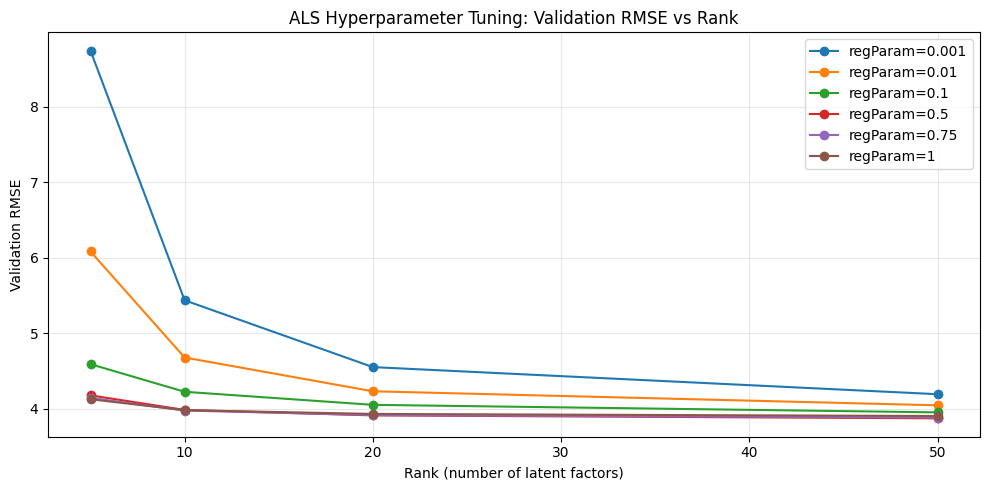

In [35]:
# visualise tuning results
results_df = pd.DataFrame(results, columns=["rank", "regParam", "Validation_RMSE"])

fig, ax = plt.subplots(figsize=(10, 5))

# plot one line per regParam
for reg in reg_params:
    subset = results_df[results_df["regParam"] == reg]
    ax.plot(subset["rank"], subset["Validation_RMSE"], marker="o", label=f"regParam={reg}")

ax.set_xlabel("Rank (number of latent factors)")
ax.set_ylabel("Validation RMSE")
ax.set_title("ALS Hyperparameter Tuning: Validation RMSE vs Rank")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ALS_Hyperparameter_Tuning_Validation_RMSE_vs_Rank.png", dpi=300, bbox_inches="tight")
plt.show()

evaluation and comparison
ranking metrics additional to RMSE

RMSE has limitations:
It treats all errors equally- but we mainly care about predicting high ratings correctly
It doesn't capture whether the top recommendations are relevant


useing Precision@K — the fraction of recommended items that are relevant.

RMSE measures rating prediction accuracy but the reccomendation quality is also about if the items are relevent so use the precision accuracy to see if recomended items are relevent

In [36]:
#ranking evaluation
# precision@K
#the proportion of the top-K recommended items that are relevant

def evaluate_precision_at_k(model, test_df, k=10, relevance_threshold=4.0):
    #evaluate_preciison@K for an ALS model
    #relevant items are ones with rating >= relevance_threshold in the test set

    #keep only relevant test interactions
    relevant_test = test_df.filter(F.col("rating") >= relevance_threshold)
    test_users = relevant_test.select("user_idx").distinct()

    #recommend only for users in the test set
    # subset faster than recommendForAllUsers
    user_recs = model.recommendForUserSubset(test_users, k)

    # flatten the nested recommendation structure
    recs_flat = user_recs.select(
        F.col("user_idx"),
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("user_idx"),
        F.col("rec.item_idx").alias("item_idx")
    )

    #match recommended items against relevant items
    # use an inner join to check relevance
    precision_df = recs_flat.join(
        relevant_test,
        ["user_idx", "item_idx"],
        "inner"
    ).groupBy("user_idx").agg(
        (F.count("item_idx") / F.lit(k)).alias("user_p")
    )

    #include users with zero hits
    # handles users who got 0 relevant recs - dont include in the inner join
    # joins back to the test_users to ensure the average includes the zeros
    final_avg = precision_df.join(test_users, "user_idx", "right") \
        .fillna(0, subset=["user_p"]) \
        .agg(F.avg("user_p")).first()[0]

    return final_avg

In [37]:
def evaluate_precision_at_k_for_user_ids(model, test_df, ratings_indexed_df, user_ids, k=10, relevance_threshold=4.0):
    test_user_map = ratings_indexed_df.select("user_id", "user_idx").dropDuplicates()

    eval_user_idxs = test_user_map.filter(
        F.col("user_id").isin(user_ids)
    ).select("user_idx").distinct()

    relevant_test = test_df.filter(F.col("rating") >= relevance_threshold).join(
        eval_user_idxs, "user_idx", "inner"
    )

    test_users = relevant_test.select("user_idx").distinct()

    user_recs = model.recommendForUserSubset(test_users, k)

    recs_flat = user_recs.select(
        F.col("user_idx"),
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("user_idx"),
        F.col("rec.item_idx").alias("item_idx")
    )

    precision_df = recs_flat.join(
        relevant_test,
        ["user_idx", "item_idx"],
        "inner"
    ).groupBy("user_idx").agg(
        (F.count("item_idx") / F.lit(k)).alias("user_p")
    )

    final_avg = precision_df.join(test_users, "user_idx", "right") \
        .fillna(0, subset=["user_p"]) \
        .agg(F.avg("user_p")).first()[0]

    return final_avg

In [38]:
# evaluates asl models recommendation acuracy by calculating  precision at different K values k(5,10,20,50)
print(f"{'K':>5} {'Precision@K':>15}")
print("-" * 25)

precisions = []

for k in [5, 10, 20, 50]:
    p = evaluate_precision_at_k(model, test_full_als, k=k)
    precisions.append((k, p))
    print(f"{k:>5} {p:>15.6f}")

    K     Precision@K
-------------------------
    5        0.003614
   10        0.001880
   20        0.000964
   50        0.000408


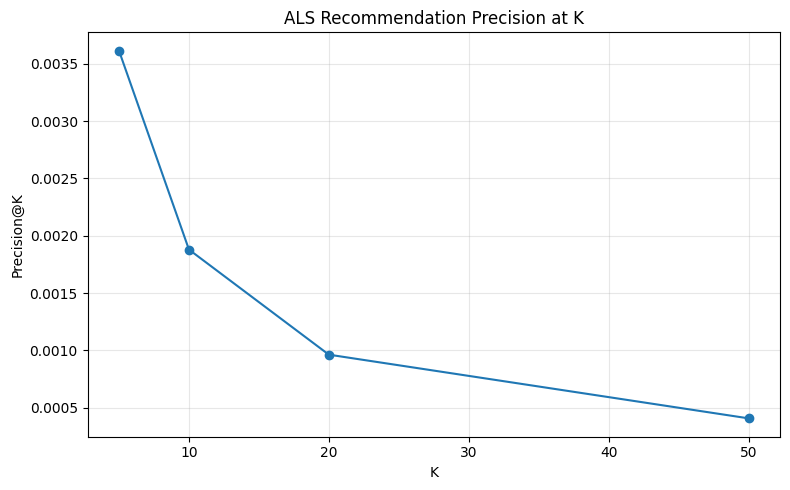

In [39]:
# graph - precision@k
precision_pd = pd.DataFrame(precisions, columns=["K", "Precision"])

plt.figure(figsize=(8,5))
plt.plot(precision_pd["K"], precision_pd["Precision"], marker="o")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("ALS Recommendation Precision at K")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ALS_Recommendation_Precision_at_K.png", dpi=300, bbox_inches="tight")
plt.show()

coverage measures what fraction of the item catalog the system can recommend. Low coverage means the system only recommends a narrow set of popular items.

In [40]:

def compute_coverage(model, products_df, k=10, sample_size=50000):

    #compute approximate catalog using a sample of users

    # gets list of user IDs known by model
    user_col_name = model.getUserCol() # This dynamically gets "user_idx"
    all_users = model.userFactors.select(F.col("id").alias(user_col_name))

    total_users = all_users.count()

    # smaple users if theres too many
    if total_users > sample_size:
        fraction = sample_size / total_users
        user_subset = all_users.sample(withReplacement=False, fraction=fraction).limit(sample_size)
        print(f"Sampling {sample_size:,} users out of {total_users:,} for coverage calculation...")
    else:
        user_subset = all_users

    # uses recommendForUserSubset instead of recommendForAllUsers
    # more stable and memory-efficient
    #generates recommended for that subset
    user_recs = model.recommendForUserSubset(user_subset, k)

    # generate unique recommended items
    recommended_items = user_recs.select(
        F.explode("recommendations").alias("rec")
    ).select(
        F.col("rec.item_idx").alias("item_idx")
    ).distinct()

    num_recommended = recommended_items.count()

    # gets total catalog count
    # assuming products_df has the total unique items
    total_products = products_df.select("parent_asin").distinct().count()

    coverage = num_recommended / total_products

    print(f"Items recommended to sample: {num_recommended:,}")
    print(f"Total in catalog:           {total_products:,}")
    print(f"Estimated Coverage:         {coverage:.2%}")

    return coverage

In [41]:
#calculates the catalog coverage of the recommender system, measures the proportion of products in the dataset that the model is capable of recommending
coverage = compute_coverage(model, products)

Sampling 50,000 users out of 513,636 for coverage calculation...
Items recommended to sample: 67,929
Total in catalog:           112,590
Estimated Coverage:         60.33%


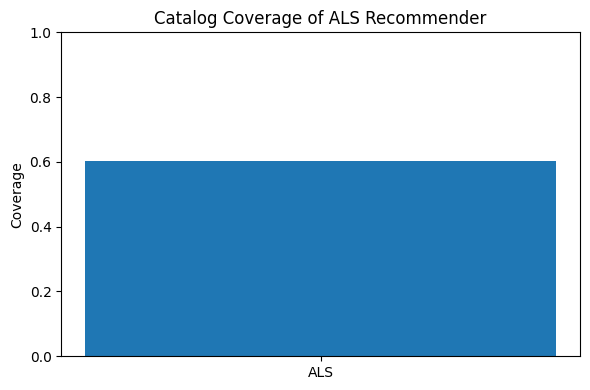

In [42]:
# graph -catalog coverage
coverage_pd = pd.DataFrame({
    "Model": ["ALS"],
    "Coverage": [coverage]
})

plt.figure(figsize=(6,4))
plt.bar(coverage_pd["Model"], coverage_pd["Coverage"])
plt.ylabel("Coverage")
plt.title("Catalog Coverage of ALS Recommender")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("Catalog_Coverage_of_ALS_Recommender.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
# compare recommendation methods side by side for the same user
def compare_recommendations(user_id, model, ratings_df, popularity_df, product_tfidf_df, products_df, ratings_indexed_df, alpha=0.5, top_n=10):
    print(f"\n{'='*100}")
    print(f"Recommendations for User {user_id}")
    print(f"{'='*100}")

    # user's own liked items for context
    user_top = ratings_df.filter(
        (F.col("user_id") == user_id) & (F.col("rating") >= 4.0)
    ).join(products_df, "parent_asin") \
     .select("title", "rating") \
     .orderBy(F.desc("rating")) \
     .limit(5) \
     .collect()

    print("\nUser's top-rated products:")
    for row in user_top:
        print(f" {row['rating']:.1f}  {row['title'][:70]}")

    # popularity
    print(f"\nPopularity Top {top_n}:")
    pop_recs = popularity_recommend(user_id, ratings_df, popularity_df, top_n=top_n)

    # random
    print(f"\nRandom Top {top_n}:")
    random_recommend(user_id, ratings_df, products_df, top_n=top_n)

    # content-based
    cb_recs = content_based_recommend(
        user_id,
        ratings_df,
        product_tfidf_df,
        products_df,
        top_n=top_n,
        verbose=True
    )

    # ALS
    user_idx_row = ratings_indexed_df.filter(
        F.col("user_id") == user_id
    ).select("user_idx").first()

    if user_idx_row is not None:
        user_idx_value = int(user_idx_row["user_idx"])
        user_df = spark.createDataFrame([(user_idx_value,)], ["user_idx"])

        als_recs = model.recommendForUserSubset(user_df, top_n)

        als_flat = als_recs.select(
            F.explode("recommendations").alias("rec")
        ).select(
            F.col("rec.item_idx").alias("item_idx"),
            F.col("rec.rating").alias("score")
        )

        item_lookup = ratings_indexed_df.select("item_idx", "parent_asin").dropDuplicates()

        als_named = als_flat.join(item_lookup, "item_idx") \
            .join(products_df.select("parent_asin", "title"), "parent_asin") \
            .collect()

        print(f"\nALS Collaborative Filtering Top {top_n}:")
        for i, row in enumerate(als_named[:top_n], 1):
            print(f"{i}. {row['title'][:60]:60s} | ASIN={row['parent_asin']} | score={row['score']:.4f}")
    else:
        print("\nALS Collaborative Filtering Top recommendations:")
        print("User not found in ALS indexed data.")

    # hybrid
    print(f"\nHybrid Top {top_n}:")
    hybrid_recommend(
        user_id,
        model,
        ratings_df,
        product_tfidf_df,
        products_df,
        ratings_indexed_df,
        alpha=alpha,
        top_n=top_n,
        verbose=True
    )

Hybrid Recommender

combines content-based and ALS scores:

scorehybrid=α⋅scoreCB+(1−α)⋅scoreALS

alpha = 1.0 -> pure content based
alpha = 0.0 -> pure als

Experiments with different values of  α . questions - does the hybrid outperform either individual system?

In [44]:
def hybrid_recommend(user_id, model, ratings_df, product_tfidf_df, products_df, ratings_indexed_df, alpha=0.5, top_n=10, verbose=True):

    #hybrid recommender combining normalised content-based and ALS scores

    # content-based scores
    #  build the users content profile
    user_profile, rated_ids = build_user_profile(user_id, ratings_df, product_tfidf_df)

    if user_profile is None:
        # print(f"Cannot build profile for user {user_id}")
        return None

    # broadcast profile for efficient distributed cosine scoring - the small user profile to all workers
    b_user_profile = sc.broadcast(user_profile)

    def get_cosine_sim(features):
        if features is None: return 0.0
        v1 = b_user_profile.value
        v2 = np.array(features)
        dot = np.dot(v1, v2)
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        return float(dot / norm) if norm > 0 else 0.0

    cosine_udf = F.udf(get_cosine_sim, FloatType())

    # score all unrated products using content similarity
    cb_df = product_tfidf_df.filter(~F.col("parent_asin").isin(rated_ids)) \
        .withColumn("cb_score", cosine_udf(F.col("tfidf_features")))

    # Normalize content based scores to [0,1] using min/max from the cluster
    stats = cb_df.select(F.min("cb_score"), F.max("cb_score")).first()
    cb_min, cb_max = stats[0], stats[1]
    cb_range = (cb_max - cb_min) if (cb_max is not None and cb_min is not None and cb_max > cb_min) else 1.0

    cb_df = cb_df.withColumn("cb_norm", (F.col("cb_score") - cb_min) / cb_range)

    # als scores
    user_idx_row = ratings_indexed_df.filter(F.col("user_id") == user_id).select("user_idx").first()
    if not user_idx_row: return None

    user_df = spark.createDataFrame([(int(user_idx_row["user_idx"]),)], ["user_idx"])
    # gets more than top_n to ensure we have overlap for the hybrid calculation
    als_recs = model.recommendForUserSubset(user_df, 1000)

    als_flat = als_recs.select(F.explode("recommendations").alias("rec")).select(
        F.col("rec.item_idx").alias("item_idx"),
        F.col("rec.rating").alias("als_raw_score")
    )

    # map ALS indices back to ASINs
    item_lookup = ratings_indexed_df.select("item_idx", "parent_asin").distinct()
    als_df = als_flat.join(item_lookup, "item_idx")

    # normalise ALS scores
    als_stats = als_df.select(F.min("als_raw_score"), F.max("als_raw_score")).first()
    a_min, a_max = als_stats[0], als_stats[1]
    a_range = (a_max - a_min) if (a_max is not None and a_min is not None and a_max > a_min) else 1.0

    als_df = als_df.withColumn("als_norm", (F.col("als_raw_score") - a_min) / a_range)

    #combine Scores
    # join content based scores and ALS scores on parent_asin
    hybrid_df = cb_df.join(als_df.select("parent_asin", "als_norm"), "parent_asin", "outer") \
        .fillna(0, subset=["cb_norm", "als_norm"]) \
        .withColumn("hybrid_score", (F.lit(alpha) * F.col("cb_norm")) + (F.lit(1-alpha) * F.col("als_norm")))

    # final metadata join & collect
    #adds titles and returns top items
    final_recs = hybrid_df.drop("title").join(
        products_df.select("parent_asin", "title"),
        "parent_asin"
    ) \
        .orderBy(F.col("hybrid_score").desc()) \
        .select("title", "parent_asin", "hybrid_score", "cb_norm", "als_norm") \
        .limit(top_n) \
        .collect()

    # prints recommendation table
    if verbose:
        print(f"\nHybrid Recommendations for User {user_id} (alpha={alpha}):")
        print(f"{'#':>3} {'Title':60s} {'Hybrid':>8} {'CB':>8} {'ALS':>8}")
        print("-" * 95)
        for i, row in enumerate(final_recs, 1):
            print(f"{i:3d} {str(row['title'])[:60]:60s} {row['hybrid_score']:8.4f} {row['cb_norm']:8.4f} {row['als_norm']:8.4f}")

    return final_recs

In [45]:
def evaluate_hybrid_precision_at_k(user_ids, model, train_df, test_df, product_tfidf_df, products_df, ratings_indexed_df, k=10, alpha=0.5, relevance_threshold=4.0):
    relevant_items_df = test_df.filter(
        (F.col("user_id").isin(user_ids)) & (F.col("rating") >= relevance_threshold)
    ).select("user_id", "parent_asin").distinct()

    total_precision = 0.0
    valid_users = 0

    for u_id in user_ids:
        recs = hybrid_recommend(
            u_id,
            model,
            train_df,
            product_tfidf_df,
            products_df,
            ratings_indexed_df,
            alpha=alpha,
            top_n=k,
            verbose=False
        )

        if not recs:
            continue

        user_relevant = [
            row["parent_asin"]
            for row in relevant_items_df.filter(F.col("user_id") == u_id).collect()
        ]

        if not user_relevant:
            continue

        recommended_asins = {row["parent_asin"] for row in recs}
        hits = len(recommended_asins.intersection(set(user_relevant)))

        total_precision += (hits / k)
        valid_users += 1

    avg_precision = total_precision / valid_users if valid_users > 0 else 0.0
    print(f"\nFinal Average Precision@{k}: {avg_precision:.4f}")
    return avg_precision

In [46]:
# choose alpha on VALIDATION users, but only keep users
# who have positive history in training and relevant items in validation

valid_train_users = ratings_train.filter(
    F.col("rating") >= 3.5
).select("user_id").distinct()

valid_eval_users = ratings_valid.filter(
    F.col("rating") >= 4.0
).select("user_id").distinct()

sample_users_valid = [
    row["user_id"]
    for row in valid_train_users.join(valid_eval_users, on="user_id", how="inner")
                                .limit(10)
                                .collect()
]

print("Validation users used for alpha tuning:", len(sample_users_valid))

hybrid_results = []

for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    hp = evaluate_hybrid_precision_at_k(
        user_ids=sample_users_valid,
        model=model_valid,
        train_df=ratings_train,
        test_df=ratings_valid,
        product_tfidf_df=product_tfidf,
        products_df=products,
        ratings_indexed_df=ratings_indexed,
        k=10,
        alpha=alpha
    )
    hybrid_results.append((alpha, hp))
    print(f"{alpha:>8.1f} {hp:>22.4f}")

best_alpha, best_alpha_valid_p10 = max(hybrid_results, key=lambda x: x[1])
print(f"\nBest alpha on validation: {best_alpha}")

Validation users used for alpha tuning: 10
User AE22SZ62FCLRK4RQNMVZGOUYLJAA: profile built from 1 highly-rated products
User AE25FOZEGSDS6SD342N7M7ZGAN6Q: profile built from 1 highly-rated products
User AE2D3Q6344PXSYHU6VSW3HYTHH7Q: profile built from 1 highly-rated products
User AE2IJMIHM4XRZXU3TW3JKZVHDTJQ: profile built from 1 highly-rated products
User AE2VAC2YOW5N3DLYBQ6LKVIB6WPQ: profile built from 4 highly-rated products
User AE3IGJOPJP6LFXEJTIXFJVSJLILA: profile built from 5 highly-rated products
User AE3VECDEFDN2FMTWBR7OZG3YSHAA: profile built from 1 highly-rated products
User AE4EBMOTJK3NXCVLN3CS24J55BOQ: profile built from 1 highly-rated products
User AE4HDGDZZXMD46WGYYPZSBA4RCPQ: profile built from 1 highly-rated products
User AE4OG34VWD4QTP6OIX5LPCDQCD6A: profile built from 3 highly-rated products

Final Average Precision@10: 0.0100
     0.0                 0.0100
User AE22SZ62FCLRK4RQNMVZGOUYLJAA: profile built from 1 highly-rated products
User AE25FOZEGSDS6SD342N7M7ZGAN

In [47]:
# demos AFTER final ALS model and best alpha exist

# inspect some product titles
products.select("title").show(20, truncate=False)

# ALS recommendations for one sample indexed user
sample_user_idx = ratings_indexed.select("user_idx").distinct().limit(1)
user_recs = model.recommendForUserSubset(sample_user_idx, 10)

print("Schema of ALS recommendations:")
user_recs.printSchema()
user_recs.show(1, truncate=False)

# ALS similar products demo
find_similar_products_als("foundation", model, ratings_indexed, products, top_n=5)

# compare methods side by side for a few users
ratings.select("user_id").distinct().show(10, truncate=False)

sample_users = [
    row["user_id"]
    for row in ratings_train.select("user_id").distinct().limit(5).collect()
]

for uid in sample_users:
    compare_recommendations(
        user_id=uid,
        model=model,
        ratings_df=ratings_train,
        popularity_df=popular_products,
        product_tfidf_df=product_tfidf,
        products_df=products,
        ratings_indexed_df=ratings_indexed,
        alpha=best_alpha,
        top_n=10
    )

# show how alpha changes hybrid recommendations
for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    hybrid_recommend(
        sample_user,
        model,
        ratings_train_full,
        product_tfidf,
        products,
        ratings_indexed,
        alpha=alpha,
        top_n=10,
        verbose=True
    )

print("\n" + "=" * 80)
print("alpha=0.0 gives pure ALS")
print("alpha=1.0 gives pure content-based")
print("Intermediate values combine both signals")

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|title                                                                                                                                                                                   |
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|howard lc008 leather conditioner 8 ounce 4 pack                                                                                                                                         |
|yes tomato detoxifying charcoal cleanser pack 2 charcoal powder tomato fruit extract gingko biloba leaf extract 5 fl oz                                                                 |
|eye patch black adult tie band 6 per pack                       

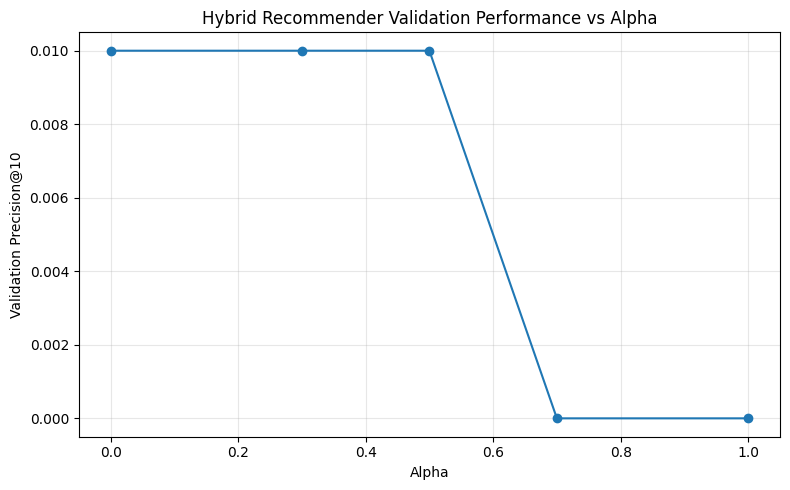

In [48]:
# graph - hybrid precision vs alpha
hybrid_pd = pd.DataFrame(hybrid_results, columns=["Alpha", "Validation Precision@10"])

plt.figure(figsize=(8,5))
plt.plot(hybrid_pd["Alpha"], hybrid_pd["Validation Precision@10"], marker="o")
plt.xlabel("Alpha")
plt.ylabel("Validation Precision@10")
plt.title("Hybrid Recommender Validation Performance vs Alpha")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Hybrid_Recommender_Performance_vs_Alpha.png", dpi=300, bbox_inches="tight")
plt.show()

Test users used for final evaluation: 10

Random Precision@10: 0.0000

Popularity Precision@10: 0.0000
User AE263BHRT5Y7AI73HAW6IUYTN3DQ: profile built from 1 highly-rated products
User AE27VWZJJ7VKJXRZC7W7MHUBNTGA: profile built from 3 highly-rated products
User AE2M4TJT7WJTIKJZQO5KRZK2S3WA: profile built from 1 highly-rated products
User AE2PLUOAQPO3Z5MNEMTSMM4YGRWA: profile built from 1 highly-rated products
User AE2PRJ3VTQZY6AUZLHSE5SZGASVA: profile built from 1 highly-rated products
User AE2SZVTNAWQKJO5IBENRWUS77BOQ: profile built from 1 highly-rated products
User AE2T2NLXRQ2VIEK4OA2LMITHY2DQ: profile built from 1 highly-rated products
User AE2VAC2YOW5N3DLYBQ6LKVIB6WPQ: profile built from 5 highly-rated products
User AE3DYFJTYKVSKL6EM2NP6O2IRNRQ: profile built from 2 highly-rated products
User AE3IGJOPJP6LFXEJTIXFJVSJLILA: profile built from 6 highly-rated products

Content-Based Precision@10: 0.0000
ALS Precision@10: 0.02
User AE263BHRT5Y7AI73HAW6IUYTN3DQ: profile built from 1 hi

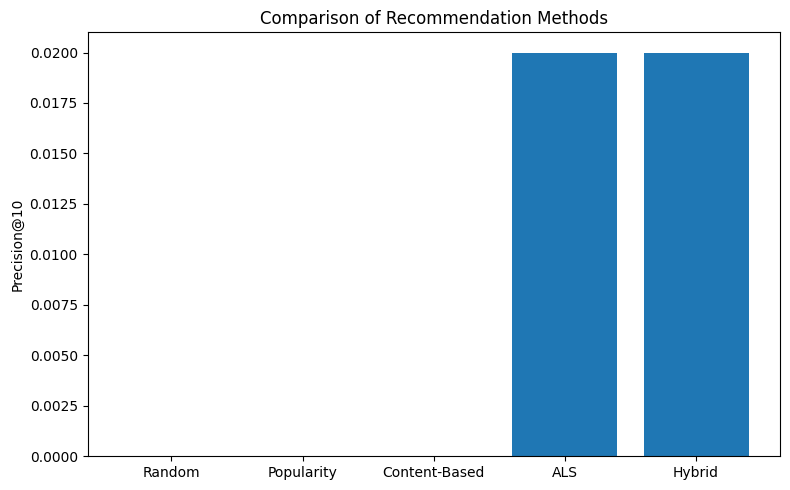

In [49]:
# final comparison across all 5 methods

# final test users: must have profile-building history in train_full
# and relevant items in test

test_train_users = ratings_train_full.filter(
    F.col("rating") >= 3.5
).select("user_id").distinct()

test_eval_users = ratings_test.filter(
    F.col("rating") >= 4.0
).select("user_id").distinct()

eval_users = [
    row["user_id"]
    for row in test_train_users.join(test_eval_users, on="user_id", how="inner")
                               .limit(10)
                               .collect()
]

print("Test users used for final evaluation:", len(eval_users))

# rebuild popularity model on all non-test training data for final evaluation
popular_products_full = ratings_train_full.groupBy("parent_asin").agg(
    F.avg("rating").alias("avg_rating"),
    F.count("*").alias("review_count")
).join(
    products.select("parent_asin", "title"),
    on="parent_asin",
    how="left"
).withColumn(
    "popularity_score",
    F.col("avg_rating") * F.log1p(F.col("review_count"))
)

random_p10 = evaluate_random_precision_at_k(
    user_ids=eval_users,
    train_df=ratings_train_full,
    test_df=ratings_test,
    products_df=products,
    k=10,
    relevance_threshold=4.0
)

popularity_p10 = evaluate_popularity_precision_at_k(
    user_ids=eval_users,
    train_df=ratings_train_full,
    test_df=ratings_test,
    popularity_df=popular_products_full,
    k=10,
    relevance_threshold=4.0
)

content_p10 = evaluate_content_precision_at_k(
    user_ids=eval_users,
    train_df=ratings_train_full,
    test_df=ratings_test,
    product_tfidf_df=product_tfidf,
    products_df=products,
    k=10,
    relevance_threshold=4.0
)

als_p10 = evaluate_precision_at_k_for_user_ids(
    model=model,
    test_df=test_full_als,
    ratings_indexed_df=ratings_indexed,
    user_ids=eval_users,
    k=10,
    relevance_threshold=4.0
)
print("ALS Precision@10:", als_p10)

hybrid_p10 = evaluate_hybrid_precision_at_k(
    user_ids=eval_users,
    model=model,
    train_df=ratings_train_full,
    test_df=ratings_test,
    product_tfidf_df=product_tfidf,
    products_df=products,
    ratings_indexed_df=ratings_indexed,
    k=10,
    alpha=best_alpha
)
print("Best Hybrid Alpha:", best_alpha)
print("Hybrid Precision@10:", hybrid_p10)

comparison_pd = pd.DataFrame({
    "Model": ["Random", "Popularity", "Content-Based", "ALS", "Hybrid"],
    "Precision@10": [random_p10, popularity_p10, content_p10, als_p10, hybrid_p10]
})

print(comparison_pd)

plt.figure(figsize=(8,5))
plt.bar(comparison_pd["Model"], comparison_pd["Precision@10"])
plt.ylabel("Precision@10")
plt.title("Comparison of Recommendation Methods")
plt.tight_layout()
plt.savefig("Comparison_of_Recommendation_Methods.png", dpi=300, bbox_inches="tight")
plt.show()

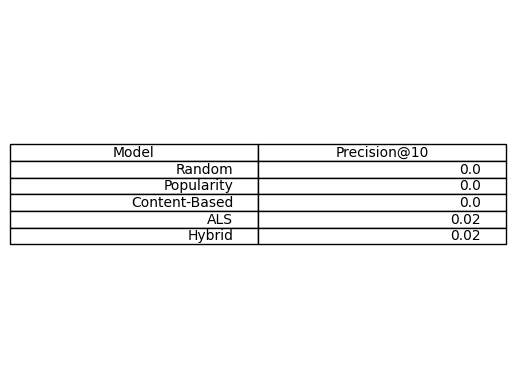

In [50]:
# save results table as an image for the report
fig, ax = plt.subplots()

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=comparison_pd.values,
    colLabels=comparison_pd.columns,
    loc='center'
)

plt.savefig("final_results_table.png", dpi=300, bbox_inches='tight')
plt.show()

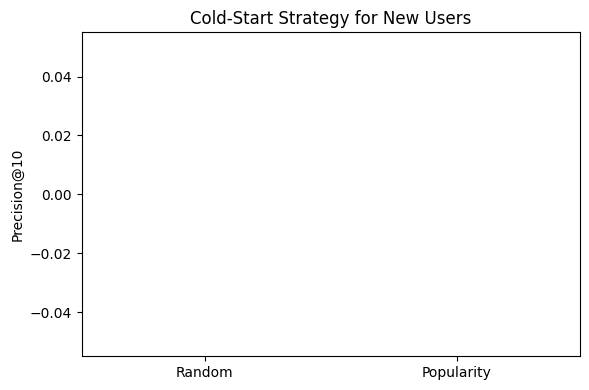

In [51]:
cold_start_pd = pd.DataFrame({
    "Method": ["Random", "Popularity"],
    "Precision@10": [random_p10, popularity_p10]
})

plt.figure(figsize=(6,4))
plt.bar(cold_start_pd["Method"], cold_start_pd["Precision@10"])
plt.ylabel("Precision@10")
plt.title("Cold-Start Strategy for New Users")
plt.tight_layout()
plt.savefig("Cold_Start_New_User_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
print("\nCold-start interpretation:")
print("- New users are handled with popularity-based recommendations because there is no interaction history.")
print("- New or sparse products are handled with content-based similarity using title/description features.")


Cold-start interpretation:
- New users are handled with popularity-based recommendations because there is no interaction history.
- New or sparse products are handled with content-based similarity using title/description features.


In [53]:
# clean - stop spark session
spark.stop()